In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# =========================
# User-defined inputs
# =========================

CSV_PATH = Path(
    "robustness_results/"
    "monte_carlo_robustness_results_80_percent_perturbation.csv"
)

OUTPUT_DIRECTORY = Path(
    "figures/"
    "robustness_metrics_boxplots"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

controllers_sorted = [
    "PID",
    "PID-GS",
    "PID-GS-FF",
]

# Three requested performance metrics.
#
# t_settle_after is settling time measured relative to the
# disturbance time.
metric_specs = {
    "metric_M": {
        "title": r"$M$",
        "ylabel": r"$M$",
        "filename": "M",
    },
    "ITAE": {
        "title": "ITAE",
        "ylabel": "ITAE",
        "filename": "ITAE",
    },
    "t_settle_after": {
        "title": "Settling Time",
        "ylabel": (
            "Settling Time After "
            "Disturbance (min)"
        ),
        "filename": "settling_time",
    },
}

color_dict = {
    "set_point_1": "#6759d4",
    "set_point_2": "#ebab4b",
    "green": "green",
    "red": "red",
    "PID": "black",
    "PID-GS": "#1f78b4",
    "FF": "#dd3497",
    "PID-FF": "#fc8d62",
    "PID-GS-FF": "#03cea4",
}

# boxplot_cfg = {
#     "figsize": (3.25, 2.6),
#     "dpi": 300,
#     "font_family": "Arial",
#     "base_fontsize": 8,
#     "title_fontsize": 8,
#     "label_fontsize": 8,
#     "tick_fontsize": 8,
#     "box_width": 0.55,
#     "box_alpha": 0.35,
#     "box_linewidth": 0.8,
#     "median_linewidth": 1.2,
#     "whisker_linewidth": 0.8,
#     "cap_linewidth": 0.8,
#     "axis_linewidth": 0.6,
#     "save_format": "svg",
# }
boxplot_cfg = {
    "figsize": (1.75, 1.6),
    "dpi": 300,
    "font_family": "Arial",
    "base_fontsize": 6,
    "title_fontsize": 6,
    "label_fontsize": 6,
    "tick_fontsize": 6,
    "box_width": 0.55,
    "box_alpha": 0.35,
    "box_linewidth": 0.8,
    "median_linewidth": 0.8,
    "whisker_linewidth": 0.8,
    "cap_linewidth": 0.8,
    "axis_linewidth": 0.6,
    "save_format": "svg",
}

# False saves all figures without showing all 147 plots inline.
# Set True to display every plot in the notebook.
show_figures = True

# Change an entry to "log" to use a logarithmic y-axis.
metric_y_scales = {
    "metric_M": "linear",
    "ITAE": "log",
    "t_settle_after": "linear",
}

In [3]:
df = pd.read_csv(
    CSV_PATH
)

required_cols = {
    "monte_carlo_id",
    "perturb_percent",
    "perturb_time",
    "controller",
    "status",
    "metric_M",
    "ITAE",
    "t_settle_after",
}

missing = (
    required_cols
    - set(df.columns)
)

if missing:
    raise ValueError(
        f"Missing required columns in "
        f"robustness CSV: {missing}"
    )

# Use only successful Monte Carlo simulations.
df = df[
    df["status"] == "ok"
].copy()

# Use only the three requested controllers.
df = df[
    df["controller"].isin(
        controllers_sorted
    )
].copy()

if df.empty:
    raise ValueError(
        "No successful Monte Carlo runs "
        "were found in the CSV."
    )

# Convert all requested metrics to numeric values.
for metric_name in metric_specs:
    df[metric_name] = pd.to_numeric(
        df[metric_name],
        errors="coerce",
    )

perturb_percents = np.sort(
    df[
        "perturb_percent"
    ].unique()
)

perturb_times = np.sort(
    df[
        "perturb_time"
    ].unique()
)

print(
    "perturb_percents:",
    perturb_percents,
)

print(
    "perturb_times:",
    perturb_times,
)

print(
    "controllers:",
    controllers_sorted,
)

display(
    df.head()
)

perturb_percents: [80.]
perturb_times: [480.]
controllers: ['PID', 'PID-GS', 'PID-GS-FF']


,monte_carlo_id,perturb_percent,perturb_time,controller,status,error_message,metric_M,t_settle_after,ITAE,rise_time,...,param_d_m,param_k_tl,param_k_tli_b,param_k_tli_u,param_d_p,param_k_fold,param_b_fold,param_n_gamma,param_R_max,param_n_tcs
0,0,80.0,480.0,PID,ok,NaN,0.383503,136.898990,1242.693095,0.0,...,0.273090,1.897839,43.461144,11.291501,0.000789,0.261032,0.970934,0.785019,3.714776,1.075109
1,0,80.0,480.0,PID-GS,ok,NaN,0.690981,204.916265,2633.520960,0.0,...,0.273090,1.897839,43.461144,11.291501,0.000789,0.261032,0.970934,0.785019,3.714776,1.075109
2,0,80.0,480.0,PID-GS-FF,ok,NaN,0.383698,130.636364,1310.972061,0.0,...,0.273090,1.897839,43.461144,11.291501,0.000789,0.261032,0.970934,0.785019,3.714776,1.075109
3,1,80.0,480.0,PID,ok,NaN,2.324138,960.000000,5738.403725,0.0,...,0.280003,2.166010,41.356040,13.502272,0.000690,0.278787,0.987801,0.764650,4.169594,1.105790
4,1,80.0,480.0,PID-GS,ok,NaN,0.507625,159.151515,1863.097203,0.0,...,0.280003,2.166010,41.356040,13.502272,0.000690,0.278787,0.987801,0.764650,4.169594,1.105790


In [4]:
def safe_number_for_filename(value):
    """
    Convert a condition value to a compact filename-safe string.
    """
    value = float(value)

    if value.is_integer():
        return str(
            int(value)
        )

    return str(value).replace(
        ".",
        "p",
    )


def finite_values(series):
    """
    Convert a pandas Series to numeric values and retain only
    finite observations.
    """
    values = pd.to_numeric(
        series,
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    return values[
        np.isfinite(values)
    ]


def condition_metric_values(
    df_in,
    perturb_percent,
    perturb_time,
    metric_name,
):
    """
    Return metric arrays in the exact controller order used on
    the x-axis.

    Empty controller groups are returned as a NaN placeholder so
    that the x-axis location is preserved.
    """
    condition_mask = (
        np.isclose(
            df_in[
                "perturb_percent"
            ],
            perturb_percent,
        )
        & np.isclose(
            df_in[
                "perturb_time"
            ],
            perturb_time,
        )
    )

    condition_df = df_in[
        condition_mask
    ]

    values_by_controller = []
    sample_counts = []

    for controller in controllers_sorted:
        controller_values = finite_values(
            condition_df.loc[
                condition_df[
                    "controller"
                ] == controller,
                metric_name,
            ]
        )

        sample_counts.append(
            len(controller_values)
        )

        # Matplotlib requires at least one value for a box position.
        if len(controller_values) == 0:
            controller_values = np.array([
                np.nan
            ])

        values_by_controller.append(
            controller_values
        )

    return (
        values_by_controller,
        sample_counts,
    )


def summarize_condition_metric(
    perturb_percent,
    perturb_time,
    metric_name,
    values_by_controller,
):
    """
    Calculate the five-number summary represented by each box plot.

    The saved values are:
        minimum
        first quartile
        median
        third quartile
        maximum
    """
    rows = []

    for controller, values in zip(
        controllers_sorted,
        values_by_controller,
    ):
        values = np.asarray(
            values,
            dtype=float,
        )

        values = values[
            np.isfinite(values)
        ]

        if values.size == 0:
            rows.append({
                "perturb_percent": (
                    perturb_percent
                ),
                "perturb_time": (
                    perturb_time
                ),
                "controller": controller,
                "metric": metric_name,
                "count": 0,
                "minimum": np.nan,
                "q1": np.nan,
                "median": np.nan,
                "q3": np.nan,
                "maximum": np.nan,
            })

            continue

        rows.append({
            "perturb_percent": (
                perturb_percent
            ),
            "perturb_time": (
                perturb_time
            ),
            "controller": controller,
            "metric": metric_name,
            "count": int(
                values.size
            ),
            "minimum": float(
                np.min(values)
            ),
            "q1": float(
                np.quantile(
                    values,
                    0.25,
                )
            ),
            "median": float(
                np.median(values)
            ),
            "q3": float(
                np.quantile(
                    values,
                    0.75,
                )
            ),
            "maximum": float(
                np.max(values)
            ),
        })

    return rows

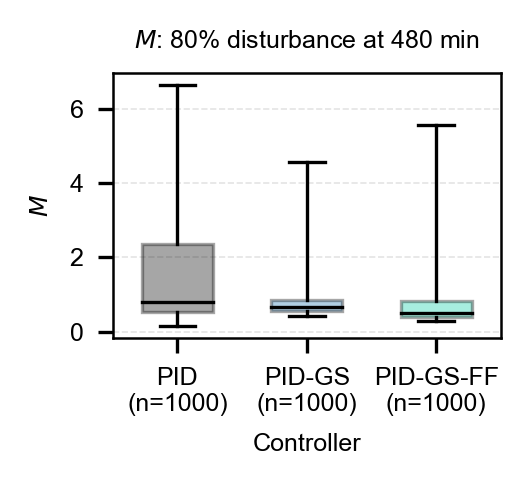

Saved: figures/robustness_metrics_boxplots/boxplot_M_perturb_percent_80_perturb_time_480.svg


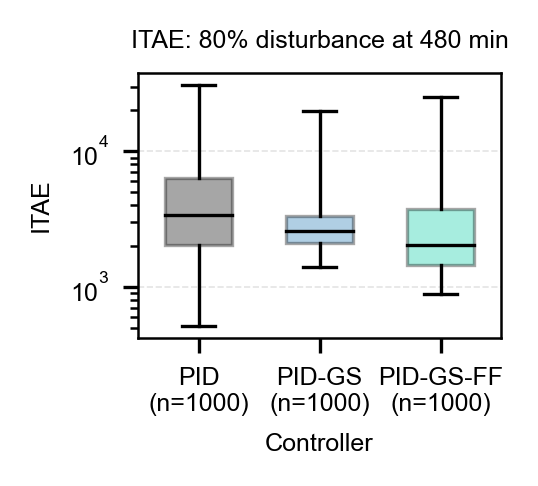

Saved: figures/robustness_metrics_boxplots/boxplot_ITAE_perturb_percent_80_perturb_time_480.svg


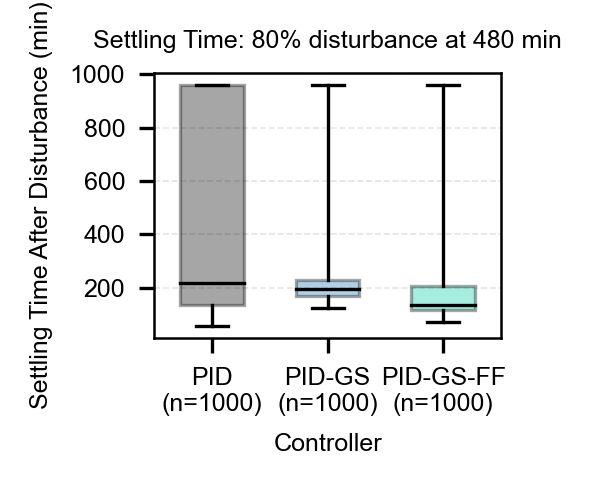

Saved: figures/robustness_metrics_boxplots/boxplot_settling_time_perturb_percent_80_perturb_time_480.svg


In [5]:
plt.rcParams.update({
    "font.family": (
        boxplot_cfg[
            "font_family"
        ]
    ),
    "font.size": (
        boxplot_cfg[
            "base_fontsize"
        ]
    ),
    "axes.labelsize": (
        boxplot_cfg[
            "label_fontsize"
        ]
    ),
    "axes.titlesize": (
        boxplot_cfg[
            "title_fontsize"
        ]
    ),
    "xtick.labelsize": (
        boxplot_cfg[
            "tick_fontsize"
        ]
    ),
    "ytick.labelsize": (
        boxplot_cfg[
            "tick_fontsize"
        ]
    ),
})

boxplot_summary_rows = []

for pp in perturb_percents:
    for pt in perturb_times:
        for (
            metric_name,
            metric_info,
        ) in metric_specs.items():

            (
                values_by_controller,
                sample_counts,
            ) = condition_metric_values(
                df_in=df,
                perturb_percent=pp,
                perturb_time=pt,
                metric_name=metric_name,
            )

            boxplot_summary_rows.extend(
                summarize_condition_metric(
                    perturb_percent=pp,
                    perturb_time=pt,
                    metric_name=metric_name,
                    values_by_controller=(
                        values_by_controller
                    ),
                )
            )

            # Skip the plot only if every controller has no data.
            if sum(sample_counts) == 0:
                print(
                    f"Skipping empty condition: "
                    f"{pp}% at {pt} min, "
                    f"{metric_name}"
                )

                continue

            fig, ax = plt.subplots(
                figsize=(
                    boxplot_cfg[
                        "figsize"
                    ]
                ),
                dpi=(
                    boxplot_cfg[
                        "dpi"
                    ]
                ),
            )

            # whis=(0, 100) makes the whiskers represent the
            # observed minimum and maximum.
            boxplot_kwargs = {
                "widths": (
                    boxplot_cfg[
                        "box_width"
                    ]
                ),
                "patch_artist": True,
                "whis": (0, 100),
                "showfliers": False,
                "showmeans": False,
                "boxprops": {
                    "linewidth": (
                        boxplot_cfg[
                            "box_linewidth"
                        ]
                    ),
                    "edgecolor": "black",
                },
                "whiskerprops": {
                    "linewidth": (
                        boxplot_cfg[
                            "whisker_linewidth"
                        ]
                    ),
                    "color": "black",
                },
                "capprops": {
                    "linewidth": (
                        boxplot_cfg[
                            "cap_linewidth"
                        ]
                    ),
                    "color": "black",
                },
                "medianprops": {
                    "linewidth": (
                        boxplot_cfg[
                            "median_linewidth"
                        ]
                    ),
                    "color": "black",
                },
            }

            # Newer Matplotlib versions use tick_labels.
            # Older versions use labels.
            try:
                bp = ax.boxplot(
                    values_by_controller,
                    tick_labels=(
                        controllers_sorted
                    ),
                    **boxplot_kwargs,
                )

            except TypeError:
                bp = ax.boxplot(
                    values_by_controller,
                    labels=(
                        controllers_sorted
                    ),
                    **boxplot_kwargs,
                )

            # Apply the controller colors to each box.
            for patch, controller in zip(
                bp["boxes"],
                controllers_sorted,
            ):
                patch.set_facecolor(
                    color_dict[
                        controller
                    ]
                )

                patch.set_alpha(
                    boxplot_cfg[
                        "box_alpha"
                    ]
                )

            ax.set_title(
                f"{metric_info['title']}: "
                f"{pp:g}% disturbance at "
                f"{pt:g} min"
            )

            ax.set_xlabel(
                "Controller"
            )

            ax.set_ylabel(
                metric_info[
                    "ylabel"
                ]
            )

            ax.set_yscale(
                metric_y_scales[
                    metric_name
                ]
            )

            # Show the valid Monte Carlo sample count for each controller.
            tick_labels = [
                f"{controller}\n(n={count})"
                for controller, count in zip(
                    controllers_sorted,
                    sample_counts,
                )
            ]

            ax.set_xticklabels(
                tick_labels
            )

            for spine in [
                "top",
                "right",
                "bottom",
                "left",
            ]:
                ax.spines[
                    spine
                ].set_visible(
                    True
                )

                ax.spines[
                    spine
                ].set_linewidth(
                    boxplot_cfg[
                        "axis_linewidth"
                    ]
                )

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=(
                    boxplot_cfg[
                        "tick_fontsize"
                    ]
                ),
            )

            ax.grid(
                axis="y",
                linestyle="--",
                linewidth=0.4,
                alpha=0.35,
            )

            fig.tight_layout()

            pp_label = (
                safe_number_for_filename(
                    pp
                )
            )

            pt_label = (
                safe_number_for_filename(
                    pt
                )
            )

            output_path = (
                OUTPUT_DIRECTORY
                / (
                    f"boxplot_"
                    f"{metric_info['filename']}"
                    f"_perturb_percent_"
                    f"{pp_label}"
                    f"_perturb_time_"
                    f"{pt_label}."
                    f"{boxplot_cfg['save_format']}"
                )
            )

            fig.savefig(
                output_path,
                format=(
                    boxplot_cfg[
                        "save_format"
                    ]
                ),
                dpi=(
                    boxplot_cfg[
                        "dpi"
                    ]
                ),
                bbox_inches="tight",
                transparent=True,
            )

            if show_figures:
                plt.show()
            else:
                plt.close(fig)

            print(
                f"Saved: {output_path}"
            )

In [6]:
# Save the exact minimum, quartiles, median, and maximum
# represented by every box plot.

df_boxplot_summary = pd.DataFrame(
    boxplot_summary_rows
)

SUMMARY_CSV_PATH = (
    OUTPUT_DIRECTORY
    / "boxplot_five_number_summary.csv"
)

df_boxplot_summary.to_csv(
    SUMMARY_CSV_PATH,
    index=False,
)

print(
    f"Saved box-plot summary to: "
    f"{SUMMARY_CSV_PATH}"
)

display(
    df_boxplot_summary.head()
)

Saved box-plot summary to: figures/robustness_metrics_boxplots/boxplot_five_number_summary.csv


,perturb_percent,perturb_time,controller,metric,count,minimum,q1,median,q3,maximum
0,80.0,480.0,PID,metric_M,1000,0.162358,0.527949,0.804016,2.376592,6.657674
1,80.0,480.0,PID-GS,metric_M,1000,0.415382,0.567709,0.662768,0.842295,4.577638
2,80.0,480.0,PID-GS-FF,metric_M,1000,0.274022,0.405073,0.513376,0.831982,5.580887
3,80.0,480.0,PID,ITAE,1000,520.686740,2038.266762,3400.444297,6406.056688,30779.488043
4,80.0,480.0,PID-GS,ITAE,1000,1414.756371,2115.344545,2581.604203,3345.616015,19958.236778


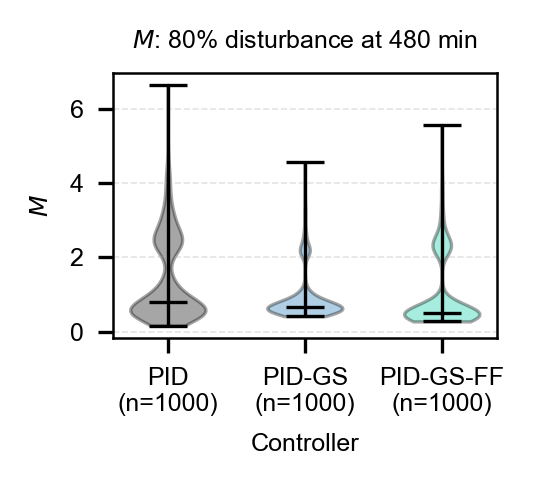

Saved: figures/robustness_metrics_violinplots/violinplot_M_perturb_percent_80_perturb_time_480.svg


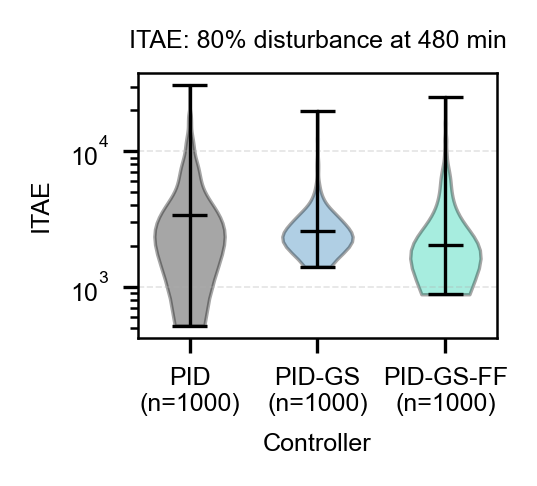

Saved: figures/robustness_metrics_violinplots/violinplot_ITAE_perturb_percent_80_perturb_time_480.svg


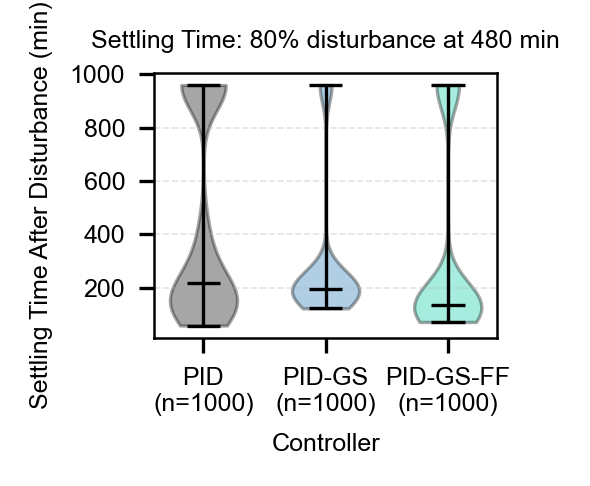

Saved: figures/robustness_metrics_violinplots/violinplot_settling_time_perturb_percent_80_perturb_time_480.svg


In [7]:
# %%
VIOLIN_OUTPUT_DIRECTORY = Path(
    "figures/robustness_metrics_violinplots"
)
VIOLIN_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

for pp in perturb_percents:
    for pt in perturb_times:
        for metric_name, metric_info in metric_specs.items():

            (
                values_by_controller,
                sample_counts,
            ) = condition_metric_values(
                df_in=df,
                perturb_percent=pp,
                perturb_time=pt,
                metric_name=metric_name,
            )

            if sum(sample_counts) == 0:
                continue

            fig, ax = plt.subplots(
                figsize=boxplot_cfg["figsize"],
                dpi=boxplot_cfg["dpi"],
            )

            # Only pass controllers with valid data to violinplot.
            valid_positions = []
            valid_values = []
            valid_controllers = []

            for i, (controller, values, count) in enumerate(
                zip(
                    controllers_sorted,
                    values_by_controller,
                    sample_counts,
                ),
                start=1,
            ):
                if count > 0:
                    valid_positions.append(i)
                    valid_values.append(
                        values[np.isfinite(values)]
                    )
                    valid_controllers.append(controller)

            vp = ax.violinplot(
                valid_values,
                positions=valid_positions,
                widths=boxplot_cfg["box_width"],
                showmeans=False,
                showmedians=True,
                showextrema=True,
            )

            # Same controller colors as the box plots.
            for body, controller in zip(
                vp["bodies"],
                valid_controllers,
            ):
                body.set_facecolor(
                    color_dict[controller]
                )
                body.set_edgecolor("black")
                body.set_linewidth(
                    boxplot_cfg["box_linewidth"]
                )
                body.set_alpha(
                    boxplot_cfg["box_alpha"]
                )

            # Keep median and extrema styling consistent.
            vp["cmedians"].set_color("black")
            vp["cmedians"].set_linewidth(
                boxplot_cfg["median_linewidth"]
            )

            for key in ["cbars", "cmins", "cmaxes"]:
                vp[key].set_color("black")
                vp[key].set_linewidth(
                    boxplot_cfg["whisker_linewidth"]
                )

            ax.set_title(
                f"{metric_info['title']}: "
                f"{pp:g}% disturbance at "
                f"{pt:g} min"
            )

            ax.set_xlabel("Controller")
            ax.set_ylabel(metric_info["ylabel"])

            ax.set_yscale(
                metric_y_scales[metric_name]
            )

            tick_labels = [
                f"{controller}\n(n={count})"
                for controller, count in zip(
                    controllers_sorted,
                    sample_counts,
                )
            ]

            ax.set_xticks(
                range(
                    1,
                    len(controllers_sorted) + 1,
                )
            )
            ax.set_xticklabels(tick_labels)

            for spine in [
                "top",
                "right",
                "bottom",
                "left",
            ]:
                ax.spines[spine].set_visible(True)
                ax.spines[spine].set_linewidth(
                    boxplot_cfg["axis_linewidth"]
                )

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=boxplot_cfg[
                    "tick_fontsize"
                ],
            )

            ax.grid(
                axis="y",
                linestyle="--",
                linewidth=0.4,
                alpha=0.35,
            )

            fig.tight_layout()

            pp_label = safe_number_for_filename(pp)
            pt_label = safe_number_for_filename(pt)

            output_path = (
                VIOLIN_OUTPUT_DIRECTORY
                / (
                    f"violinplot_"
                    f"{metric_info['filename']}"
                    f"_perturb_percent_{pp_label}"
                    f"_perturb_time_{pt_label}."
                    f"{boxplot_cfg['save_format']}"
                )
            )

            fig.savefig(
                output_path,
                format=boxplot_cfg["save_format"],
                dpi=boxplot_cfg["dpi"],
                bbox_inches="tight",
                transparent=True,
            )

            if show_figures:
                plt.show()
            else:
                plt.close(fig)

            print(f"Saved: {output_path}")

In [8]:
# %%
# Pairwise paired t-tests between controllers

from itertools import combinations
from scipy.stats import ttest_rel

ttest_rows = []

for pp in perturb_percents:
    for pt in perturb_times:
        condition_df = df[
            np.isclose(df["perturb_percent"], pp)
            & np.isclose(df["perturb_time"], pt)
        ]

        for metric_name in metric_specs:

            # One row per Monte Carlo realization,
            # one column per controller.
            paired = condition_df.pivot_table(
                index="monte_carlo_id",
                columns="controller",
                values=metric_name,
                aggfunc="first",
            )

            for controller_1, controller_2 in combinations(
                controllers_sorted, 2
            ):
                if (
                    controller_1 not in paired.columns
                    or controller_2 not in paired.columns
                ):
                    continue

                pair_data = paired[
                    [controller_1, controller_2]
                ].replace(
                    [np.inf, -np.inf], np.nan
                ).dropna()

                if len(pair_data) < 2:
                    continue

                values_1 = pair_data[controller_1].to_numpy()
                values_2 = pair_data[controller_2].to_numpy()

                t_stat, p_value = ttest_rel(
                    values_1,
                    values_2,
                    alternative="two-sided",
                )

                ttest_rows.append({
                    "perturb_percent": pp,
                    "perturb_time": pt,
                    "metric": metric_name,
                    "controller_1": controller_1,
                    "controller_2": controller_2,
                    "n_pairs": len(pair_data),
                    "mean_1": np.mean(values_1),
                    "mean_2": np.mean(values_2),
                    "mean_difference_2_minus_1": (
                        np.mean(values_2 - values_1)
                    ),
                    "t_statistic": t_stat,
                    "p_value": p_value,
                    "significant_0.05": p_value < 0.05,
                })


df_ttests = pd.DataFrame(ttest_rows)

display(df_ttests)

# Save results
TTEST_CSV_PATH = (
    OUTPUT_DIRECTORY
    / "pairwise_controller_paired_ttests.csv"
)

df_ttests.to_csv(
    TTEST_CSV_PATH,
    index=False,
)

print(f"Saved paired t-test results to: {TTEST_CSV_PATH}")

,perturb_percent,perturb_time,metric,controller_1,controller_2,n_pairs,mean_1,mean_2,mean_difference_2_minus_1,t_statistic,p_value,significant_0.05
0,80.0,480.0,metric_M,PID,PID-GS,1000,1.398633,0.906857,-0.491775,17.064659,1.710558e-57,True
1,80.0,480.0,metric_M,PID,PID-GS-FF,1000,1.398633,0.991417,-0.407216,18.504389,5.792718e-66,True
2,80.0,480.0,metric_M,PID-GS,PID-GS-FF,1000,0.906857,0.991417,0.084560,-4.469439,8.739267e-06,True
3,80.0,480.0,ITAE,PID,PID-GS,1000,4874.948634,3078.343735,-1796.604899,16.325119,2.754861e-53,True
4,80.0,480.0,ITAE,PID,PID-GS-FF,1000,4874.948634,3237.565244,-1637.383390,20.535288,1.875403e-78,True
5,80.0,480.0,ITAE,PID-GS,PID-GS-FF,1000,3078.343735,3237.565244,159.221509,-2.741134,6.232028e-03,True
6,80.0,480.0,t_settle_after,PID,PID-GS,1000,443.600449,294.272552,-149.327897,13.952615,1.485615e-40,True
7,80.0,480.0,t_settle_after,PID,PID-GS-FF,1000,443.600449,330.666024,-112.934426,12.104907,1.429372e-31,True
8,80.0,480.0,t_settle_after,PID-GS,PID-GS-FF,1000,294.272552,330.666024,36.393472,-4.258398,2.253172e-05,True


Saved paired t-test results to: figures/robustness_metrics_boxplots/pairwise_controller_paired_ttests.csv


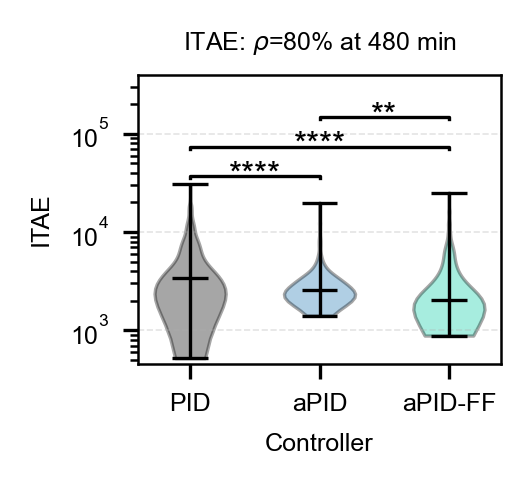

Saved: figures/robustness_metrics_violinplots_significance/violinplot_ITAE_significance_perturb_percent_80_perturb_time_480.svg


In [9]:
# %%
# ITAE violin plots with statistical-significance annotations
# Logarithmic y-axis

controller_labels = {
    'PID': 'PID',
    'PID-GS': 'aPID',
    'PID-GS-FF': 'aPID-FF'
}

SIG_OUTPUT_DIRECTORY = Path(
    "figures/robustness_metrics_violinplots_significance"
)
SIG_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)


def p_to_star(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


for pp in perturb_percents:
    for pt in perturb_times:

        values_by_controller, sample_counts = condition_metric_values(
            df_in=df,
            perturb_percent=pp,
            perturb_time=pt,
            metric_name="ITAE",
        )

        fig, ax = plt.subplots(
            figsize=boxplot_cfg["figsize"],
            dpi=boxplot_cfg["dpi"],
        )

        valid_positions = []
        valid_values = []
        valid_controllers = []

        for i, (controller, values, count) in enumerate(
            zip(
                controllers_sorted,
                values_by_controller,
                sample_counts,
            ),
            start=1,
        ):
            if count > 0:

                values = np.asarray(
                    values,
                    dtype=float,
                )

                # Log scale requires strictly positive values.
                values = values[
                    np.isfinite(values)
                    & (values > 0)
                ]

                if len(values) > 0:
                    valid_positions.append(i)
                    valid_values.append(values)
                    valid_controllers.append(controller)

        # Skip condition if no positive ITAE values are available.
        if len(valid_values) == 0:
            print(
                f"Skipping {pp}% disturbance at {pt} min: "
                "no positive ITAE values available for log scale."
            )
            plt.close(fig)
            continue

        vp = ax.violinplot(
            valid_values,
            positions=valid_positions,
            widths=boxplot_cfg["box_width"],
            showmeans=False,
            showmedians=True,
            showextrema=True,
        )

        # Same controller colors as before.
        for body, controller in zip(
            vp["bodies"],
            valid_controllers,
        ):
            body.set_facecolor(
                color_dict[controller]
            )
            body.set_edgecolor("black")
            body.set_linewidth(
                boxplot_cfg["box_linewidth"]
            )
            body.set_alpha(
                boxplot_cfg["box_alpha"]
            )

        # Median styling.
        vp["cmedians"].set_color("black")
        vp["cmedians"].set_linewidth(
            boxplot_cfg["median_linewidth"]
        )

        # Extrema styling.
        for key in ["cbars", "cmins", "cmaxes"]:
            vp[key].set_color("black")
            vp[key].set_linewidth(
                boxplot_cfg["whisker_linewidth"]
            )

        # -----------------------------------------
        # Logarithmic y-axis
        # -----------------------------------------
        ax.set_yscale("log")

        # Pairwise significance results for this condition.
        sig = df_ttests[
            np.isclose(
                df_ttests["perturb_percent"],
                pp,
            )
            & np.isclose(
                df_ttests["perturb_time"],
                pt,
            )
            & (
                df_ttests["metric"] == "ITAE"
            )
        ]

        # -----------------------------------------
        # Significance-bar placement in log space
        # -----------------------------------------
        all_vals = np.concatenate(valid_values)

        y_min = np.min(all_vals)
        y_max = np.max(all_vals)

        # Multiplicative spacing looks uniform
        # on a logarithmic axis.
        base_y = y_max * 1.15
        step_factor = 2
        bar_factor = 1.04

        controller_pos = {
            controller: i + 1
            for i, controller in enumerate(
                controllers_sorted
            )
        }

        # Show all three pairwise comparisons.
        for level, (_, row) in enumerate(
            sig.iterrows()
        ):
            x1 = controller_pos[
                row["controller_1"]
            ]
            x2 = controller_pos[
                row["controller_2"]
            ]

            y = (base_y * step_factor ** level)

            y_bar = (y * bar_factor)

            star = p_to_star(
                row["p_value"]
            )

            ax.plot(
                [x1, x1, x2, x2],
                [
                    y,
                    y_bar,
                    y_bar,
                    y,
                ],
                color="black",
                linewidth=0.8,
            )

            ax.text(
                (x1 + x2) / 2,
                y_bar * 0.7,
                star,
                ha="center",
                va="bottom",
                fontsize=8,
            )

        # -----------------------------------------
        # Log-friendly axis limits
        # -----------------------------------------
        if len(sig) > 0:
            top_y = (
                base_y
                * step_factor ** len(sig)
            )
        else:
            top_y = (
                y_max * 1.15
            )

        ax.set_ylim(
            y_min / 1.15,
            top_y * 1.40,
        )

        # -----------------------------------------
        # Labels
        # -----------------------------------------
        ax.set_title(
            # f"ITAE: {pp:g}% disturbance at {pt:g} min \n (n={count})"
            rf"ITAE: $\rho$={pp:g}% at {pt:g} min"
        )

        ax.set_xlabel(
            "Controller"
        )

        ax.set_ylabel(
            "ITAE"
        )

        ax.set_xticks(
            range(
                1,
                len(controllers_sorted) + 1,
            )
        )

        ax.set_xticklabels([
            f"{controller_labels.get(controller, controller)}"
            for controller, count in zip(
                controllers_sorted,
                sample_counts,
            )
        ])

        # -----------------------------------------
        # Axis styling
        # -----------------------------------------
        for spine in [
            "top",
            "right",
            "bottom",
            "left",
        ]:
            ax.spines[
                spine
            ].set_visible(
                True
            )

            ax.spines[
                spine
            ].set_linewidth(
                boxplot_cfg[
                    "axis_linewidth"
                ]
            )

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=boxplot_cfg[
                "tick_fontsize"
            ],
        )

        # Major log-grid lines only.
        ax.grid(
            axis="y",
            which="major",
            linestyle="--",
            linewidth=0.4,
            alpha=0.35,
        )

        fig.tight_layout()

        # -----------------------------------------
        # Save figure
        # -----------------------------------------
        pp_label = safe_number_for_filename(pp)

        pt_label = safe_number_for_filename(pt)

        output_path = (
            SIG_OUTPUT_DIRECTORY
            / (
                f"violinplot_ITAE_significance_"
                f"perturb_percent_{pp_label}_"
                f"perturb_time_{pt_label}.svg"
            )
        )

        fig.savefig(
            output_path,
            dpi=boxplot_cfg["dpi"],
            bbox_inches="tight",
            transparent=True,
        )

        plt.show()

        print(
            f"Saved: {output_path}"
        )